In [123]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, center_in_box
import os
import numpy as np
import freud
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d
from scipy.optimize import curve_fit

In [124]:
lipids = 4096
N = 16

In [125]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"
top_file = os.path.join(dir, f"setup/bilayer_{lipids}.data")
traj_file = os.path.join(dir, f"fluctuation_simulations/bilayer_{lipids}.lammpstrj")

In [126]:
top_acf_file = os.path.join(dir, "setup/bilayer_4096.data")
traj_acf_file = os.path.join(dir, "fluctuation_simulations/bilayer_acf.lammpstrj")

In [127]:
u = mda.Universe(top_file, format="DATA", atom_style = "id resid type charge x y z")
u.load_new(traj_file, format="LAMMPSDUMP", dt=0.01)

<Universe with 150255 atoms>

In [128]:
u_acf = mda.Universe(top_acf_file, format="DATA", atom_style = "id resid type charge x y z")
u_acf.load_new(traj_acf_file, format="LAMMPSDUMP", dt=0.01)

<Universe with 150255 atoms>

In [129]:
print("every frame in the acf measurement is 1 tau, as timestep = 0.001 and a frame is measured every 1000 frames.")

every frame in the acf measurement is 1 tau, as timestep = 0.001 and a frame is measured every 1000 frames.


In [130]:
lipid_atoms = u.select_atoms(f"resid 1:{lipids}")

def dpd_to_nm_transform(ts):
    ts.positions *= 0.711
    ts.dimensions[:3] *= 0.711
    return ts

transforms = [dpd_to_nm_transform, unwrap(lipid_atoms) ]
u.trajectory.add_transformations(*transforms)

In [131]:
lipid_atoms_acf = u_acf.select_atoms(f"resid 1:{lipids}")

transforms_acf = unwrap(lipid_atoms_acf)
u_acf.trajectory.add_transformations(transforms_acf)

In [132]:
top_gro = os.path.join(dir, "analysis/membrane.gro")
traj_gro = os.path.join(dir, "analysis/production.xtc")

In [133]:
u_gro = mda.Universe(top_gro, traj_gro)

gro_lipid_atoms = u_gro.select_atoms("resname *POPC")
def scale_transform(ts):
    ts.positions *= 0.1
    ts.dimensions[:3] *= 0.1
    return ts

transforms_gro = scale_transform
u_gro.trajectory.add_transformations(transforms_gro)

In [134]:
steps_gro = 3000000
frames_gro = len(u_gro.trajectory)
time_gro = u_gro.trajectory.dt
time_per_frame_gro = time_gro / frames_gro

print(f"martini time per frame {time_per_frame_gro}")

martini time per frame 0.059940059940059943


In [135]:
nematic = freud.order.Nematic()

In [136]:
def neamtic_order(universe, gro = False):

    s_values = np.zeros(len(universe.trajectory))
    directors = np.zeros((len(universe.trajectory), 3))

    lipid_res = universe.residues[:lipids]
    if gro:
        lipid_res = universe.select_atoms("resname *POPC").residues

    for frame_id, frame in enumerate(universe.trajectory):


        orientations = np.zeros((len(lipid_res), 3))

        for mol_id, mol in enumerate(lipid_res):

            positions = mol.atoms.positions
            orientation_long = (positions[7] + positions[11])/2 - positions[0]
            orientations[mol_id] = orientation_long/np.linalg.norm(orientation_long)

        nematic.compute(orientations)

        s_values[frame_id] = nematic.order
        directors[frame_id] = nematic.director

    return s_values, directors

In [137]:
def grids_per_frame(universe, N, gro):

    n_frames = len(universe.trajectory)
    lipid_res = universe.residues[:lipids]
    if gro:
        lipid_res = universe.select_atoms("resname *POPC").residues

    grids = np.zeros((n_frames, N, N))

    for frame_id, frame in enumerate(universe.trajectory):

        box_x, box_y = universe.dimensions[0], universe.dimensions[1]

        coms = []
        for mol in lipid_res:
            positions = mol.atoms.positions
            tail_middle = (positions[7] + positions[11])/2
            coms.append(tail_middle)

        x = np.array([t[0] for t in coms])
        y = np.array([t[1] for t in coms])
        z = np.array([t[2] for t in coms])


        z = z - np.mean(z)

        h_grid, x_edges, y_edges, bin_numbers = binned_statistic_2d(x, y, z, statistic="mean", bins=[N,N], range=[[0,box_x], [0,box_y]])

        h_grid = np.nan_to_num(h_grid, nan=0.0)

        grids[frame_id] = h_grid

    return grids

In [138]:
def q_norm_grid(universe, N):

    box_x, box_y = universe.dimensions[0], universe.dimensions[1]
    dx, dy = box_x/N, box_y/N

    qx, qy = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, dx)), 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(N, dy))
    QX, QY = np.meshgrid(qx, qy)

    Q_norm = np.sqrt(QX**2 + QY**2)

    return QX, QY, dx, dy, Q_norm


In [139]:
def correct_spectrum(QX, QY, dx, dy):

    sinc_x = np.sinc(QX * dx / (2 * np.pi))
    sinc_y = np.sinc(QY * dy / (2 * np.pi))

    corr_factor = sinc_x**2 * sinc_y**2

    return corr_factor


In [140]:
def fft_grid_avg(universe, grids, N):
    
    n_frames = len(universe.trajectory)

    h_qs = [np.fft.fft2(grid) for grid in grids]

    avg_power_spectrum_grid = np.zeros((N,N))

    for frame_id in range(n_frames):

        power_spectrum = np.abs(h_qs[frame_id])**2
        avg_power_spectrum_grid += power_spectrum

    avg_power_spectrum_grid = avg_power_spectrum_grid/n_frames

    box_x, box_y = universe.dimensions[0], universe.dimensions[1]
    avg_power_spectrum_grid = np.fft.fftshift(avg_power_spectrum_grid)* (box_x*box_y) / N**4

    print(f"Grid shape: {grids[0].shape}")
    print(f"Real space: <h²> = {np.mean(grids**2):.6f} σ²")
    
    parseval = np.sum(avg_power_spectrum_grid) / (box_x * box_y)
    print(f"Parseval: {parseval:.6f} σ² (sollte ≈ {np.mean(grids**2):.6f} sein)")
    
    if abs(parseval - np.mean(grids**2)) / np.mean(grids**2) > 0.1:
        print("  WARNUNG: Parseval-Theorem nicht erfüllt!")

    return avg_power_spectrum_grid

In [141]:
def radial_profile(avg_power_spectrum_grid, Q_norm, n_bins):

    q_max = np.max(Q_norm)
    q_bins = np.linspace(0, q_max, n_bins)
    q_centers = (q_bins[:-1] + q_bins[1:]) / 2

    radial_mean = []

    for i in range(len(q_bins) - 1):

        mask = (Q_norm >= q_bins[i]) & (Q_norm < q_bins[i+1])

        values = avg_power_spectrum_grid[mask]

        if len(values) > 0:
            radial_mean.append(np.mean(values))
        else:
            radial_mean.append(np.nan)

    return q_centers, np.array(radial_mean)

In [142]:
def psd(universe, n_bins, N=N, gro = False):

    grids = grids_per_frame(universe, N, gro)
    avg_power_spectrum_grid = fft_grid_avg(universe, grids, N)
    QX, QY, dx, dy, Q_norm = q_norm_grid(universe, N)
    corr = correct_spectrum(QX, QY, dx, dy)

    avg_power_spectrum_grid /= corr

    q_radial, power_radial = radial_profile(avg_power_spectrum_grid, Q_norm, n_bins)

    return q_radial, power_radial



In [143]:
def autocorrelation(universe, N=N, gro=False):

    grids = grids_per_frame(u_acf, N, gro)
    n_frames = len(grids)

    h_flat = grids.reshape(n_frames, -1)

    acf_grid = np.zeros((n_frames, N*N))

    for i in range(N*N):
        signal = h_flat[:,i]

        full_corr = np.correlate(signal, signal, mode="full")
        acf_grid[:,i] = full_corr[n_frames-1:]

    acf = np.mean(acf_grid, axis=1)
    acf_normalized = acf/acf[0]

    return acf, acf_normalized

In [144]:
# acf, acf_norm = autocorrelation(u_acf)

In [145]:
# time = np.arange(len(acf_norm))

# plt.figure(figsize=(7, 7))

# plt.plot(time, acf_norm, "o-", color="black", markersize=4, linewidth=1.5, label="ACF")

# plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# plt.xlabel(r"Time [$\tau$]")
# plt.ylabel(r"$C(t) / C(0)$")

# plt.xlim((0, len(acf_norm)-1))
# plt.ylim((-0.1, 1.1))

# plt.legend(fontsize=12, frameon=True)
# plt.grid(True, which="both", ls="-", alpha=0.3)
# plt.tight_layout()
# plt.show()

In [146]:
q_radial, power_radial = psd(u, 100)

Grid shape: (16, 16)
Real space: <h²> = 1.340509 σ²
Parseval: 1.340509 σ² (sollte ≈ 1.340509 sein)


In [147]:
def fit_func(log_q2, log_kappa_inv):

        return log_kappa_inv - 2*log_q2

def fit(q,p, lower, upper):

    fit_mask = (q**2 > lower) & (q**2 < upper) & (power_radial > 1e-10)

    q_fit, p_fit = q[fit_mask], p[fit_mask]
    
    popt, pcov = curve_fit(fit_func, np.log(q_fit**2), np.log(p_fit))

    a = popt[0]
    a_err = np.sqrt(np.diag(pcov))[0]

    kappa = 1/np.exp(a)

    print(f"kappa = {kappa}")

    q2_range = np.logspace(np.log10(lower), np.log10(upper))

    return a, a_err, q2_range

In [157]:
def fit_func_new(q2, kappa, sigma):

    return -np.log(kappa * q2**2 + sigma * q2)

def fit_new(q,p,lower,upper):

    fit_mask = (q**2 > lower) & (q**2 < upper) & (p > 1e-10)

    q_fit, p_fit = q[fit_mask], p[fit_mask]
    
    popt, pcov = curve_fit(fit_func_new, q_fit**2, np.log(p_fit), p0=[15,0])

    kappa, sigma = popt[0], popt[1] 

    print(f"kappa = {kappa}, sigma = {sigma}")

    q2_range = np.logspace(np.log10(lower), np.log10(upper))

    return kappa, sigma, q2_range

In [158]:
a, a_err, q2_range = fit(q_radial, power_radial, 0.01, 0.2)
kappa, sigma, q2_range_new = fit_new(q_radial, power_radial, 0.01, 0.15)

kappa = 1/np.exp(a)
kappa_err = kappa*a_err

tension_data = np.loadtxt(os.path.join(dir, f"fluctuation_simulations/tension_profile_{lipids}.dat"), skiprows=2, usecols=1)
print(f"lateral tension per lammps {np.mean(tension_data)}")

kappa = 5.247223510856483
kappa = 4.895309733122713, sigma = 0.018951593330629467
lateral tension per lammps 0.02614595386534161


/tmp/ipykernel_18674/4273988447.py:3: RuntimeWarning: invalid value encountered in log
  return -np.log(kappa * q2**2 + sigma * q2)


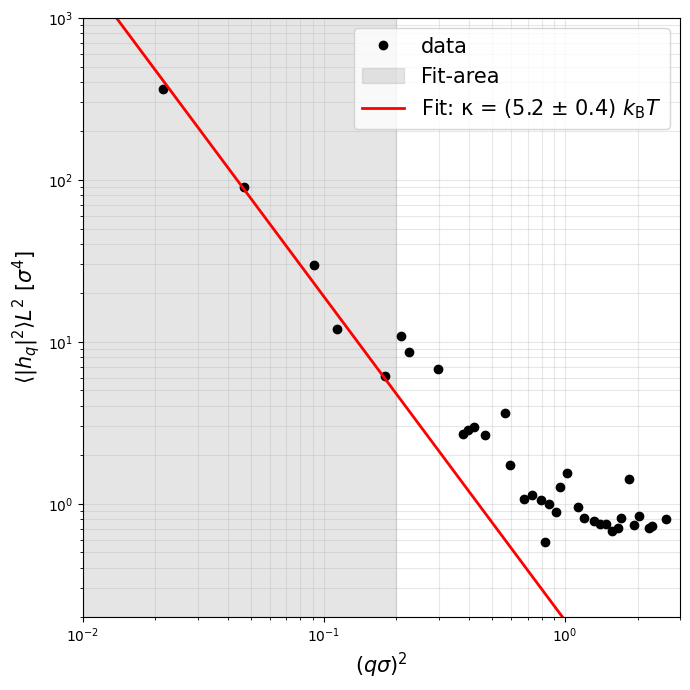

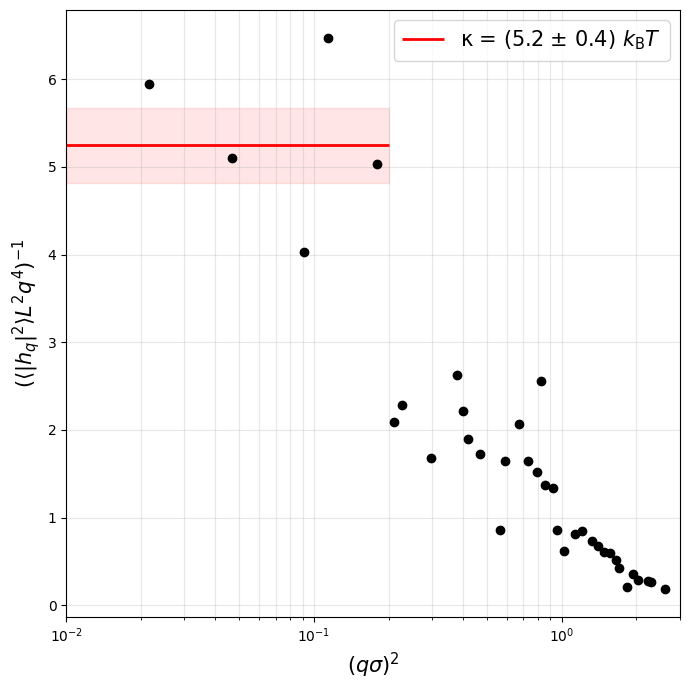

In [160]:
plt.figure(figsize=(7, 7))

mask = (power_radial > 1e-10)
q_plot, power_plot = q_radial[mask][1:], power_radial[mask][1:]

plt.loglog(q_plot**2, power_plot, "o", color="black", label="data", markersize=6)

plt.axvspan(0.01, 0.2, alpha=0.2, color='gray', label='Fit-area')

q2_range_full = np.logspace(np.log10(0.01), np.log10(1), 100)
plt.loglog(q2_range_full, np.exp(fit_func(np.log(q2_range_full), a)), "r-", linewidth=2, label=f'Fit: κ = ({kappa:.1f} $\\pm$ {kappa_err:.1f}) $k_{{\\text{{B}}}}T$')

plt.xlabel(r"$(q\sigma)^2$", fontsize=15)
plt.ylabel(r"$\langle |h_q|^2\rangle L^2$ [$\sigma^4$]", fontsize=15)

plt.xlim((0.01, 3))
plt.ylim((0.2, 1000))

plt.legend(fontsize=15, frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,7))
plt.plot(q_plot**2, 1/(power_plot*q_plot**4), "o", color="black", markersize=6)

# κ-Wert als horizontale Linie im Fit-Bereich
plt.hlines(kappa, 0.01, 0.2, colors='red', linewidth=2, label=f'κ = ({kappa:.1f} $\\pm$ {kappa_err:.1f}) $k_{{\\text{{B}}}}T$')
plt.fill_between(np.linspace(0.01, 0.2, 50), np.full(50, kappa - kappa_err), np.full(50, kappa + kappa_err), color="red", alpha=0.1)

plt.xscale("log")
plt.xlim((0.01, 3))
plt.ylabel(r"$(\langle |h_q|^2\rangle L^2q^4)^{-1}$", fontsize=15)
plt.xlabel(r"$(q\sigma)^2$", fontsize=15)
plt.legend(fontsize=15, frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

In [151]:
q_radial_gro, power_radial_gro = psd(u_gro, 100, gro = True)

Grid shape: (16, 16)
Real space: <h²> = 0.366265 σ²
Parseval: 0.366265 σ² (sollte ≈ 0.366265 sein)


In [152]:
a_gro, a_err_gro, q2_range_gro = fit(q_radial_gro, power_radial_gro, 0.02, 0.2)
a,b,q_range = fit_new(q_radial_gro, power_radial_gro, 0.01, 0.1)

kappa_gro = 1/np.exp(a_gro)
kappa_gro_err = kappa_gro*a_err_gro

kappa = 19.037850015566068
kappa = 14.44558698652622, sigma = 0.28194121099012853


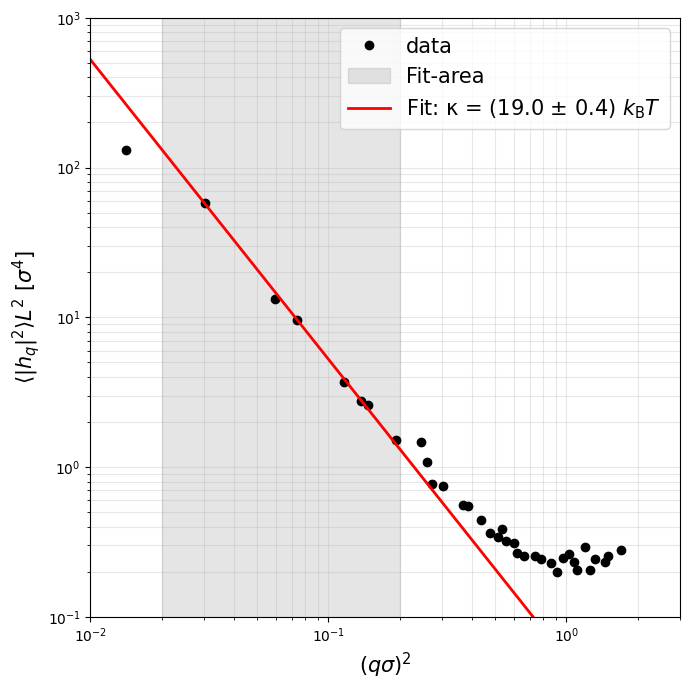

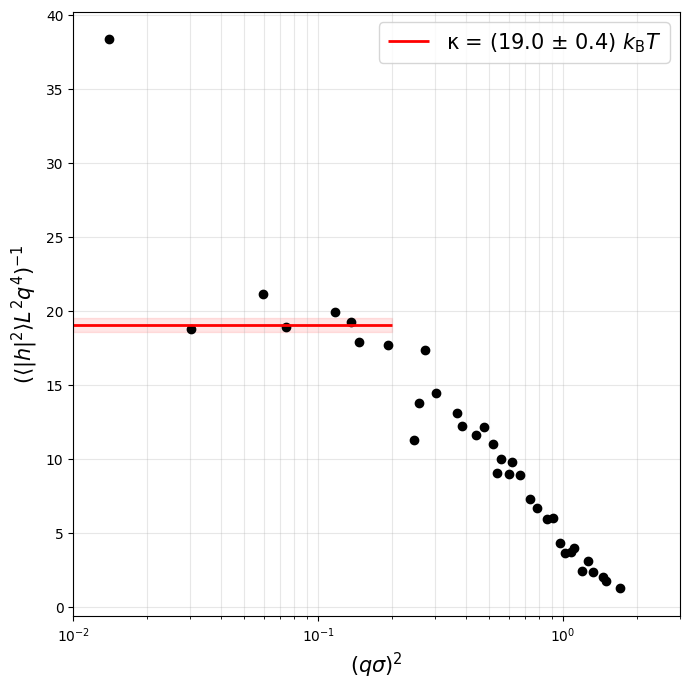

In [161]:
plt.figure(figsize=(7, 7))

mask_gro = (power_radial_gro > 1e-10)
q_plot_gro, power_plot_gro = q_radial_gro[mask_gro][1:], power_radial_gro[mask_gro][1:]

plt.loglog(q_plot_gro**2, power_plot_gro, "o", color="black", label="data", markersize=6)

plt.axvspan(0.02, 0.2, alpha=0.2, color='gray', label='Fit-area')

q2_range_full = np.logspace(np.log10(0.01), np.log10(1), 100)
plt.loglog(q2_range_full, np.exp(fit_func(np.log(q2_range_full), a_gro)), 
           "r-", linewidth=2, label=f'Fit: κ = ({kappa_gro:.1f} $\\pm$ {kappa_gro_err:.1f}) $k_{{\\text{{B}}}}T$')

plt.xlabel(r"$(q\sigma)^2$", fontsize=15)
plt.ylabel(r"$\langle |h_q|^2 \rangle L^2$ [$\sigma^4$]", fontsize=15)

plt.xlim((0.01, 3))
plt.ylim((0.1, 1000))

plt.legend(fontsize=15, frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plt.plot(q_plot_gro**2, 1/(power_plot_gro*q_plot_gro**4), "o", color="black", markersize=6)

# κ-Wert als horizontale Linie im Fit-Bereich
plt.hlines(kappa_gro, 0.01, 0.2, colors='red', linewidth=2, label=f'κ = ({kappa_gro:.1f} $\\pm$ {kappa_gro_err:.1f}) $k_{{\\text{{B}}}}T$')
plt.fill_between(np.linspace(0.01, 0.2, 50), np.full(50, kappa_gro - kappa_gro_err), np.full(50, kappa_gro + kappa_gro_err), color="red", alpha=0.1)

plt.xscale("log")
plt.xlim((0.01, 3))
plt.ylabel(r"$(\langle |h|^2\rangle L^2q^4)^{-1}$", fontsize=15)
plt.xlabel(r"$(q\sigma)^2$", fontsize=15)
plt.legend(fontsize=15, frameon=True)
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()